
# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante: Mario César Barrera Salas

C.C: 1003290195

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.

 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

In [4]:
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Frecuencia natural = 24.790 GHz
Frecuencia de Rabi = 2.479 GHz
Frecuencia efectiva = 2.772 GHz


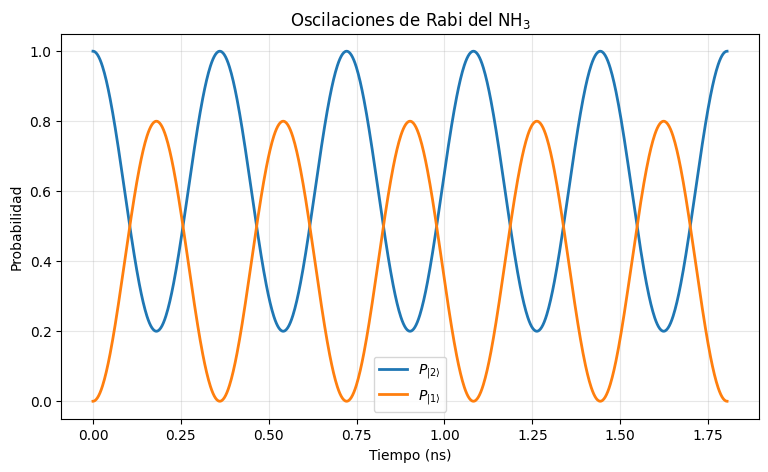

In [2]:
# Frecuencia natural (Hz)
f0 = 24.79e9
# Frecuencia angular natural (rad/s)
Omega = 2*np.pi*f0
# Frecuencia de Rabi (supuesta)
Omega_R = 0.1*Omega
# Detuning
delta = Omega_R/2
# Frecuencia generalizada de Rabi
Omega_eff = np.sqrt(Omega_R**2 + delta**2)

# Conversión a Hz
f_R = Omega_R/(2*np.pi)
f_eff = Omega_eff/(2*np.pi)

print("Frecuencia natural = %.3f GHz"%(f0/1e9))
print("Frecuencia de Rabi = %.3f GHz"%(f_R/1e9))
print("Frecuencia efectiva = %.3f GHz"%(f_eff/1e9))


# Tiempo y probabilidades
T = 2*np.pi/Omega_eff
t = np.linspace(0,5*T,1000)

P1 = (Omega_R**2/Omega_eff**2) * np.sin(Omega_eff*t/2)**2
P2 = 1-P1


# Gráficando ando
plt.figure(figsize=(9,5))

plt.plot(t*1e9,P2,label=r"$P_{|2\rangle}$",lw=2)
plt.plot(t*1e9,P1,label=r"$P_{|1\rangle}$",lw=2)

plt.xlabel("Tiempo (ns)")
plt.ylabel("Probabilidad")
plt.title("Oscilaciones de Rabi del NH$_3$")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

In [7]:
# Crear circuito de 2 qubits y 2 bits clásicos
qc = QuantumCircuit(2, 2)

# Crear superposición
qc.h(0)

# Entrelazar ambos qubits
qc.cx(0, 1)

# Medición
qc.measure([0, 1], [0, 1])

# Dibujar el circuito
print(qc.draw())


# Simulación
simulator = AerSimulator()

job = simulator.run(qc, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

plt.show()

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
{'11': 510, '00': 514}
